In [ ]:
# code to mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# change directory to where titanic.csv is located
%cd drive/MyDrive/'Colab Notebooks'

/content/drive/MyDrive/Colab Notebooks


In [ ]:
# import common libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
import random

In [ ]:
Income = pd.read_csv('Income2.csv')
Income

,Experience,GPA,Age,Income,CreditScore,NoCars,ParkingTickets,NewestCarYear,NumberKids,Education
0,11,242,24,51126,359,2,1,2016,6,HS
1,10,248,25,52306,361,2,2,2018,5,HS
2,11,242,25,51103,361,2,1,2015,6,HS
3,10,248,26,52283,363,2,2,2017,5,HS
4,10,236,24,51444,384,1,2,2019,5,HS
...,...,...,...,...,...,...,...,...,...,...
205,5,389,45,81912,835,2,0,2024,1,PHD
206,6,378,42,81302,839,0,1,2017,0,PHD
207,10,395,46,92559,839,1,1,2021,1,PHD
208,6,378,43,81279,841,0,1,2016,0,PHD


In [ ]:
NewIncome = Income.sample(n = 10000, replace=True)
NewIncome

,Experience,GPA,Age,Income,CreditScore,NoCars,ParkingTickets,NewestCarYear,NumberKids,Education
158,8,391,45,92207,731,1,0,2023,0,PHD
104,22,271,41,68035,646,1,2,2014,1,BS
121,11,275,29,57468,675,1,0,2010,0,BS
21,11,242,24,50957,510,2,1,2004,6,HS
137,7,380,44,81730,689,0,1,2023,0,PHD
...,...,...,...,...,...,...,...,...,...,...
203,5,389,44,81935,833,2,0,2025,1,PHD
191,15,327,37,70299,781,1,1,2018,0,MBA
24,13,273,29,58928,524,2,3,2015,5,HS
181,14,315,33,67783,771,2,2,2023,1,MBA


In [ ]:
#5(a)

Income.shape[1]

10

In [ ]:
#5(b)

Income.shape[0]

210

In [ ]:
#5(c)

Income['CreditScore'].nunique()

166

In [ ]:
#5(d)

(Income['Education'] == 'MBA').sum()

np.int64(91)

In [ ]:
#5(e)

Income.isna().sum()

,0
Experience,0
GPA,0
Age,0
Income,0
CreditScore,0
NoCars,0
ParkingTickets,0
NewestCarYear,0
NumberKids,0
Education,0


In [ ]:
#6(a)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier


y = np.array(Income['Education'])
X = Income[['Experience', 'GPA', 'Age', 'Income', 'CreditScore', 'NoCars', 'ParkingTickets', 'NewestCarYear', 'NumberKids']]

# Create a Random Forest Classifier
RandomForest_IncomeTree = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)

# Fit the model to the data
RandomForest_IncomeTree.fit(X, y)

y_pred_rf = RandomForest_IncomeTree.predict(X)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate accuracy of Random Forest
accuracy = metrics.accuracy_score(y, y_pred_rf)

# Calculate confusion matrix
conf_matrix = metrics.confusion_matrix(y, y_pred_rf)

# Print accuracy, and confusion matrix
print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)



Accuracy: 1.0

Confusion Matrix:
 [[30  0  0  0]
 [ 0 51  0  0]
 [ 0  0 91  0]
 [ 0  0  0 38]]


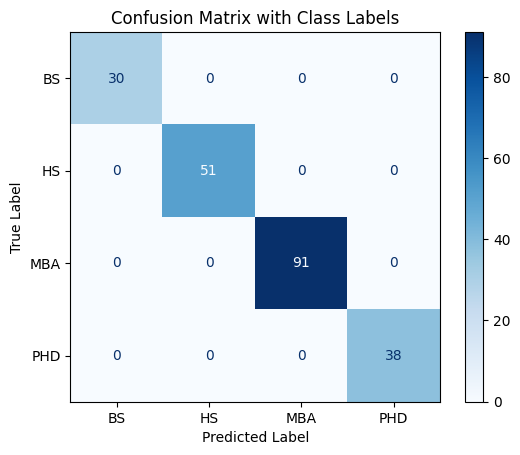

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Get unique class labels from the true labels
class_labels = np.unique(y)

# Display the confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix with Class Labels')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generate and print the classification report
report = classification_report(y, y_pred_rf)
print("\nClassification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

          BS       1.00      1.00      1.00        30
          HS       1.00      1.00      1.00        51
         MBA       1.00      1.00      1.00        91
         PHD       1.00      1.00      1.00        38

    accuracy                           1.00       210
   macro avg       1.00      1.00      1.00       210
weighted avg       1.00      1.00      1.00       210



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=42)
print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (63, 9)
X_test shape: (147, 9)
y_train shape: (63,)
y_test shape: (147,)


In [ ]:
RandomForest_IncomeTree_new = RandomForestClassifier(n_estimators=500, random_state=42)
RandomForest_IncomeTree_new.fit(X_train, y_train)
print("New RandomForestClassifier trained successfully with 500 estimators.")

New RandomForestClassifier trained successfully with 500 estimators.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy_new = accuracy_score(y_test, y_pred_new_rf)
precision_new = precision_score(y_test, y_pred_new_rf, average='weighted')
recall_new = recall_score(y_test, y_pred_new_rf, average='weighted')
f1_new = f1_score(y_test, y_pred_new_rf, average='weighted')
conf_matrix_new = confusion_matrix(y_test, y_pred_new_rf)

print(f"Accuracy on test set: {accuracy_new:.4f}")
print(f"Precision on test set: {precision_new:.4f}")
print(f"Recall on test set: {recall_new:.4f}")
print(f"F1-score on test set: {f1_new:.4f}")
print("Confusion Matrix on test set:\n", conf_matrix_new)

Accuracy on test set: 0.9048
Precision on test set: 0.9217
Recall on test set: 0.9048
F1-score on test set: 0.9015
Confusion Matrix on test set:
 [[20  0  0  0]
 [ 9 24  2  2]
 [ 0  1 64  0]
 [ 0  0  0 25]]


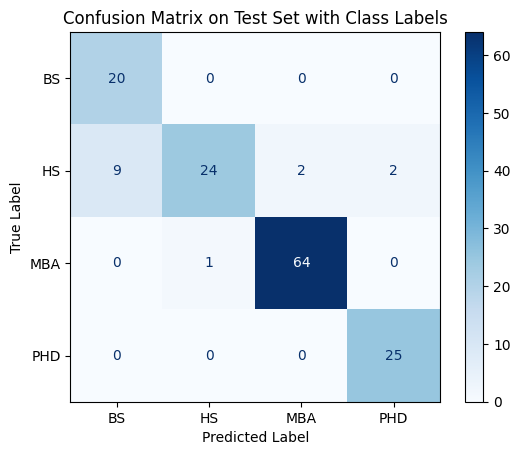

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Get unique class labels from the true labels for the test set
class_labels_test = np.unique(y_test)

# Display the confusion matrix with labels
disp_new = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_new, display_labels=class_labels_test)
disp_new.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Set with Class Labels')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()